# Clasificación de Residuos — Modelo D0: EfficientNetV2B0 Full

---

## Contexto del Experimento

Este notebook forma parte de una **serie de experimentos de Transfer Learning** que aplica la técnica de la tijera: partimos del modelo más complejo (D0) y reducimos progresivamente la cabeza para encontrar el punto óptimo de simplicidad sin perder rendimiento.

### Estrategia Experimental

- **Punto de partida**: Serie A (CNNs desde cero) — mejor resultado A4/A5 ~0.78 F1
- **Enfoque**: Transfer Learning con EfficientNetV2B0 preentrenado en ImageNet, backbone completamente descongelado
- **Observable**: ¿Cuál es el techo de rendimiento con la cabeza más compleja?

Cada modelo se implementa en un archivo independiente dentro de la carpeta `models/` del proyecto.

---

## Arquitectura del Modelo D0

### Descripción

**EfficientNetV2B0 Full** es el punto de partida de la serie descendente: la cabeza más compleja, con BatchNormalization tras el GAP, Dense(256) y Dropout(0.5). Establece el techo de rendimiento a partir del cual se simplifica progresivamente.

### Posición en la Serie Descendente

| Componente | D0 (Este modelo) | D1 (Siguiente) |
|------------|-----------------|----------------|
| **Backbone** | EfficientNetV2B0 descongelado | EfficientNetV2B0 descongelado |
| **Cabeza** | GAP → BN → Dense(256) → Dropout(0.5) → softmax | GAP → Dense(256) → Dropout(0.4) → softmax |
| **Parámetros** | 6,253,910 | 6,248,790 |

**Hipótesis**: La cabeza más compleja con BatchNorm y Dropout agresivo establece el rendimiento máximo alcanzable. Los modelos siguientes comprueban si se puede mantener ese rendimiento simplificando la cabeza.

---

## Resumen resultado final rendimiento en el conjunto de test

| Modelo | Parámetros | Accuracy | Precision | Recall | F1-Score |
|--------|----------:|--------:|----------:|-------:|--------:|
| A1 (SimpleCNN) | 210 | 0.4921 | 0.4257 | 0.4326 | 0.4150 |
| A2 (CNN Small) | 1,094 | 0.6100 | 0.6600 | 0.5600 | 0.5700 |
| A3 (CNN Medium) | 19,782 | 0.7263 | 0.7114 | 0.6884 | 0.6973 |
| A4 (CNN Large) | 94,918 | 0.7816 | 0.7643 | 0.7741 | 0.7578 |
| **D0 (EffNet Full)** | **6,253,910** | **0.9316** | **0.9199** | **0.9121** | **0.9139** |

### Rendimiento por clase (Test)

| Clase | Precision | Recall | F1-Score | Support |
|-------|----------:|-------:|---------:|--------:|
| cardboard | 0.95 | 0.98 | 0.97 | 60 |
| glass | 1.00 | 0.86 | 0.92 | 76 |
| metal | 0.86 | 0.98 | 0.92 | 62 |
| paper | 0.96 | 0.96 | 0.96 | 89 |
| plastic | 0.92 | 0.95 | 0.93 | 73 |
| trash | 0.83 | 0.75 | 0.79 | 20 |

**Nota**: D0 establece el mejor resultado de toda la serie con F1=0.9139 en test, superando ampliamente a las CNNs desde cero (~0.78). La clase `trash` obtiene aquí su mejor resultado de la serie (F1=0.79), beneficiándose de la mayor capacidad del modelo. Los modelos D1–D4 exploran si es posible mantener este rendimiento con cabezas más simples.

---

## Implementación

A continuación se entrena y evalúa el modelo D0 usando el pipeline estándar del proyecto.

---
## 0. Configuración del entorno (Colab)


In [13]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"Memory growth activado en {len(gpus)} GPU(s)")

print(tf.__version__)

Memory growth activado en 1 GPU(s)
2.20.0


In [14]:
# ========================================
# 1. IMPORTS Y CONFIGURACION
# ========================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import keras

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Agregar ruta del proyecto al path (carpeta padre de notebooks)
sys.path.insert(0, '..')

# Importar funciones de utilidad
from src.utils import initialize_project

---
## 1. Carga de datos


In [15]:
# ========================================
# 2. CARGA DE DATOS Y CONFIGURACION
# ========================================

X_train, y_train, X_val, y_val, X_test, y_test, class_names = initialize_project()

Ejecutando en local

Cargando datos desde: /home/gosacar/Profundo/notebooks/../data/processed/trashnet_224x224.npz
  X.shape: (2527, 224, 224, 3)
  y.shape: (2527,)
  Clases: cardboard, glass, metal, paper, plastic, trash

División estratificada (seed=44):
  Train: 1768 imágenes (70%)
  Val:   379 imágenes (15%)
  Test:  380 imágenes (15%)


In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

SEED       = 44
BATCH_SIZE = 16
NUM_CLASSES = len(class_names)

augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
], name='augmentation')

def make_dataset(X, y, training=False):
    # Forzar que la carga inicial ocurra en CPU
    with tf.device('/CPU:0'):
        ds = tf.data.Dataset.from_tensor_slices((X, y))
        if training:
            ds = ds.shuffle(len(X), seed=SEED)
            ds = ds.map(lambda x, y: (augmentation(x, training=True), y),
                        num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

ds_train = make_dataset(X_train, y_train, training=True)
ds_val   = make_dataset(X_val,   y_val)
ds_test  = make_dataset(X_test,  y_test)

print('Datasets listos')

Datasets listos


---
## 2. Definición del modelo


In [17]:
# ── CAMBIAR ESTAS DOS LÍNEAS SEGÚN EL MODELO ─────────────────────────────
from models.D0_effnet_full import build_effnet_full as build_model

# Ejemplos para otros modelos:
# from A2_cnn_small        import build_cnn_small        as build_model
# from A3_cnn_medium       import build_cnn_medium       as build_model
# from A4_cnn_large        import build_cnn_large        as build_model
# from A5_D5_cnn_frontier  import build_cnn_frontier     as build_model
# from D4_effnet_minimal   import build_effnet_minimal   as build_model
# from D3_effnet_gap       import build_effnet_gap       as build_model
# from D2_effnet_head      import build_effnet_head      as build_model
# from D1_effnet_top       import build_effnet_top       as build_model
# from D0_effnet_full      import build_effnet_full      as build_model


model = build_model(input_shape=(224, 224, 3), num_classes=6)
model.summary()

Model: "D0_EffNet_Full"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GAP (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN (BatchNormalization)         │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,253,910 (23.86 MB)

 Trainable params: 6,190,742 (23.62 MB)

 Non-trainable params: 63,168 (246.75 KB)

---
## 3. Entrenamiento 

In [18]:
HAS_PHASE2 = False                 
MODEL_NAME = 'D0_EffNet_Full'

cb_early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=30,                   
    restore_best_weights=True,
    mode='max',
    verbose=1
)

cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=30, min_lr=1e-6, verbose=1)

cb_checkpoint = callbacks.ModelCheckpoint(
    filepath=f'best_{MODEL_NAME}_phase1.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5,         # ← era 3e-4
        weight_decay=1e-4
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_p1 = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=300,
    callbacks=[cb_early_stop, cb_reduce_lr, cb_checkpoint],
    verbose=1
)

Epoch 1/300
111/111 ━━━━━━━━━━━━━━━━━━━━ 48s 199ms/step - accuracy: 0.2042 - loss: 2.6621 - val_accuracy: 0.2612 - val_loss: 1.7502 - learning_rate: 1.0000e-05
Epoch 2/300
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.2619 - loss: 2.2777 - val_accuracy: 0.3140 - val_loss: 1.6726 - learning_rate: 1.0000e-05
Epoch 3/300
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.3247 - loss: 2.0235 - val_accuracy: 0.3852 - val_loss: 1.5821 - learning_rate: 1.0000e-05
Epoch 4/300
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.3801 - loss: 1.7552 - val_accuracy: 0.4591 - val_loss: 1.4351 - learning_rate: 1.0000e-05
Epoch 5/300
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.4434 - loss: 1.5962 - val_accuracy: 0.5277 - val_loss: 1.2824 - learning_rate: 1.0000e-05
Epoch 6/300
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.4943 - loss: 1.4248 - val_accuracy: 0.5884 - val_loss: 1.2088 - learning_rate: 1.0000e-05
Epoch 7/300
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/s

---
## 4. Curvas de entrenamiento

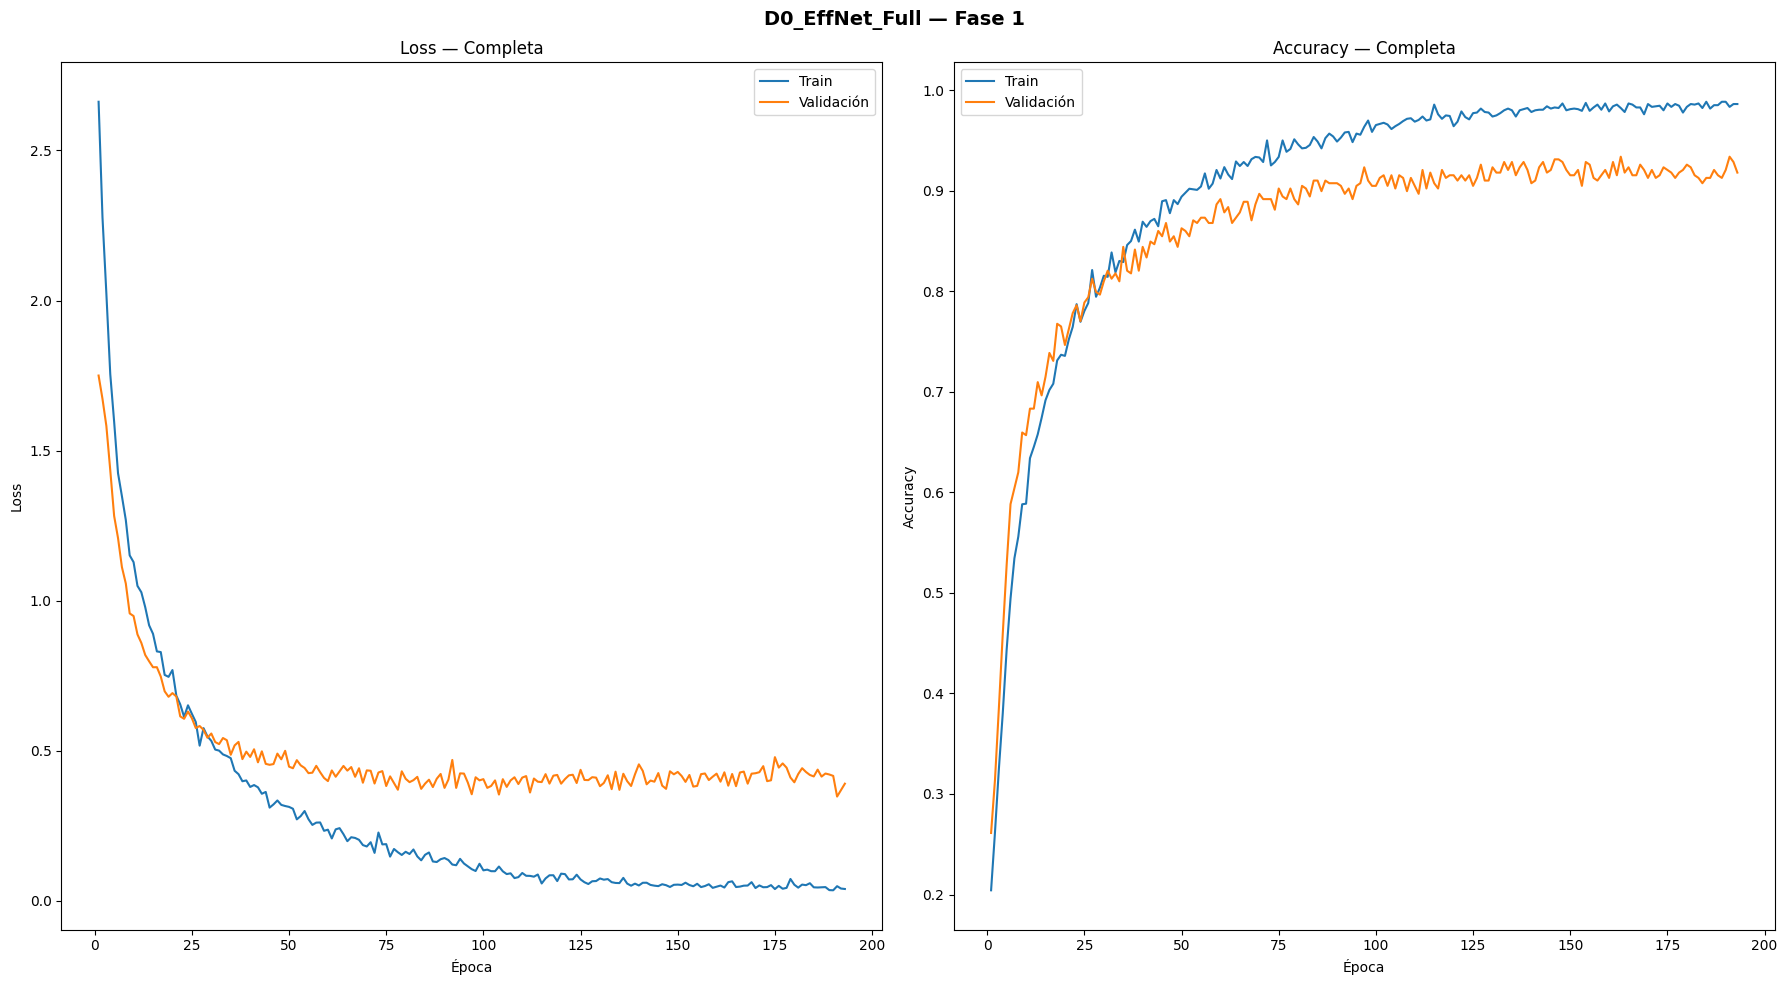

In [19]:
def smooth(values, weight=0.85):
    """Suavizado exponencial (similar a TensorBoard)."""
    smoothed, last = [], values[0]
    for v in values:
        last = last * weight + (1 - weight) * v
        smoothed.append(last)
    return smoothed


def plot_training(history, title='', phase=1):
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    epochs   = range(1, len(loss) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(18, 10))
    fig.suptitle(f'{title} — Fase {phase}', fontsize=14, fontweight='bold')

    # ── Fila 1: Loss ─────────────────────────────────────────────────────────
    # 1a) Curva completa
    axes[0].plot(epochs, loss,     label='Train')
    axes[0].plot(epochs, val_loss, label='Validación')
    axes[0].set_title('Loss — Completa')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend()

    # ── Fila 2: Accuracy ─────────────────────────────────────────────────────
    axes[1].plot(epochs, acc,     label='Train')
    axes[1].plot(epochs, val_acc, label='Validación')
    axes[1].set_title('Accuracy — Completa')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
    axes[1].legend()


    plt.tight_layout()
    plt.savefig(f'curvas_{MODEL_NAME}_fase{phase}.png', dpi=150)
    plt.show()


plot_training(history_p1, title=MODEL_NAME, phase=1)



---
## 5. Evaluación — Train / Val / Test


In [20]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_split(model, ds, y_true, split_name):
    """Calcula métricas usando el dataset en batches (evita OOM en GPU)."""
    y_pred = np.argmax(model.predict(ds, verbose=0), axis=1)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f'[{split_name:>5}]  Acc={acc:.4f}  Prec={prec:.4f}  '
          f'Rec={rec:.4f}  F1={f1:.4f}')
    return {'split': split_name, 'acc': acc,
            'prec': prec, 'rec': rec, 'f1': f1, 'y_pred': y_pred}

# Dataset de train SIN augmentation, solo para evaluación
ds_train_eval = make_dataset(X_train, y_train, training=False)

print('-' * 60)
print(f'Modelo: {MODEL_NAME}')
print('-' * 60)
res_train = evaluate_split(model, ds_train_eval, y_train, 'Train')
res_val   = evaluate_split(model, ds_val,        y_val,   'Val')
res_test  = evaluate_split(model, ds_test,       y_test,  'Test')
print('-' * 60)

------------------------------------------------------------
Modelo: D0_EffNet_Full
------------------------------------------------------------
[Train]  Acc=0.9966  Prec=0.9955  Rec=0.9972  F1=0.9963
[  Val]  Acc=0.9340  Prec=0.9297  Rec=0.9321  F1=0.9276
[ Test]  Acc=0.9395  Prec=0.9263  Rec=0.9193  F1=0.9213
------------------------------------------------------------


In [21]:
# ── Número de parámetros (para la tabla del README) ──────────────────────────
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])

print(f'Parámetros totales    : {total_params:,}')
print(f'Parámetros entrenables: {trainable_params:,}')

Parámetros totales    : 6,253,910
Parámetros entrenables: 6,190,742


---
## 6. Matriz de confusión

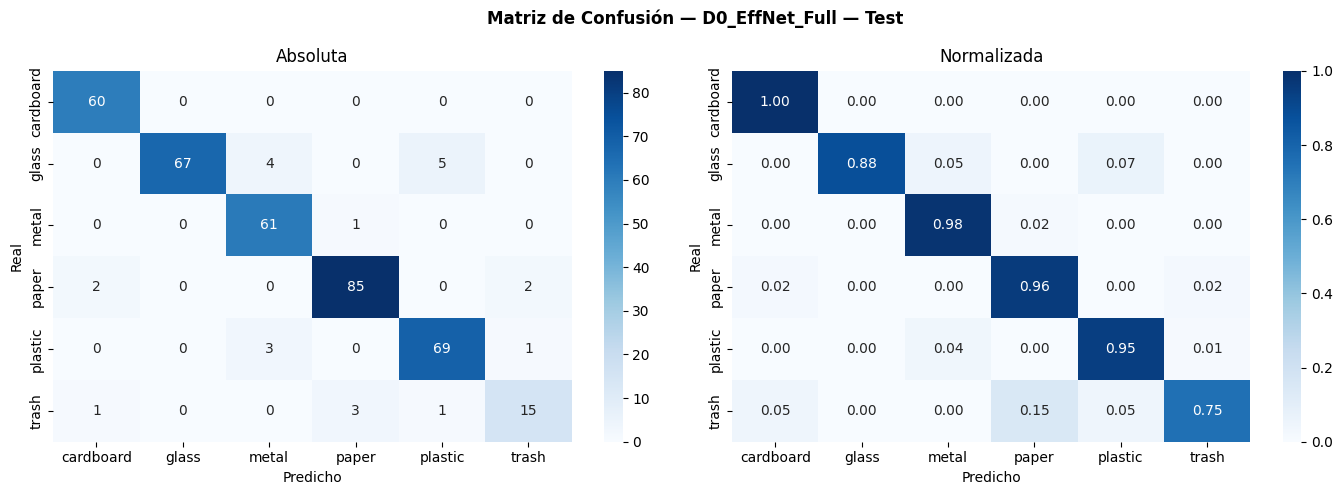

              precision    recall  f1-score   support

   cardboard       0.95      1.00      0.98        60
       glass       1.00      0.88      0.94        76
       metal       0.90      0.98      0.94        62
       paper       0.96      0.96      0.96        89
     plastic       0.92      0.95      0.93        73
       trash       0.83      0.75      0.79        20

    accuracy                           0.94       380
   macro avg       0.93      0.92      0.92       380
weighted avg       0.94      0.94      0.94       380



In [22]:
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, title='Test'):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Matriz de Confusión — {title}', fontweight='bold')

    for ax, data, fmt, ttl in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2f'],
        ['Absoluta', 'Normalizada']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_title(ttl)
        ax.set_xlabel('Predicho')
        ax.set_ylabel('Real')

    plt.tight_layout()
    plt.savefig(f'confusion_{MODEL_NAME}.png', dpi=150)
    plt.show()


plot_confusion_matrix(y_test, res_test['y_pred'], title=f'{MODEL_NAME} — Test')
print(classification_report(y_test, res_test['y_pred'],
                             target_names=class_names))


---
## 7. Resumen


In [23]:
print('─' * 90)
for res in [res_train, res_val, res_test]:
    print(
        f"| **{MODEL_NAME}** | {total_params:,} | {res['split']:>5} "
        f"| {res['acc']:.4f} | {res['prec']:.4f} "
        f"| {res['rec']:.4f} | {res['f1']:.4f} |"
    )
print('─' * 90)

──────────────────────────────────────────────────────────────────────────────────────────
| **D0_EffNet_Full** | 6,253,910 | Train | 0.9966 | 0.9955 | 0.9972 | 0.9963 |
| **D0_EffNet_Full** | 6,253,910 |   Val | 0.9340 | 0.9297 | 0.9321 | 0.9276 |
| **D0_EffNet_Full** | 6,253,910 |  Test | 0.9395 | 0.9263 | 0.9193 | 0.9213 |
──────────────────────────────────────────────────────────────────────────────────────────
